In [4]:
pip install "dask[distributed]"

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 722 kB 14.2 MB/s eta 0:00:01
     |████████████████████████████████| 43 kB 3.3 MB/s  eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


Prepared data found at prepared_data.pkl. Loading it...
Splitting data into training and testing sets...
Separating features and target variable...
Training data shape: (1131205, 17)
Testing data shape: (860278, 17)
Training the model...
Starting model training...
[LightGBM] [Info] Number of positive: 602162, number of negative: 602162
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3528
[LightGBM] [Info] Number of data points in the train set: 1204324, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

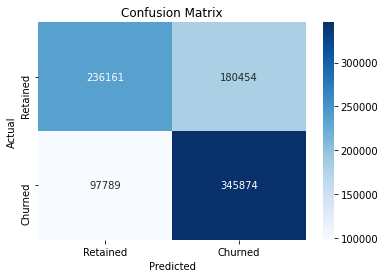

Displaying feature importance...


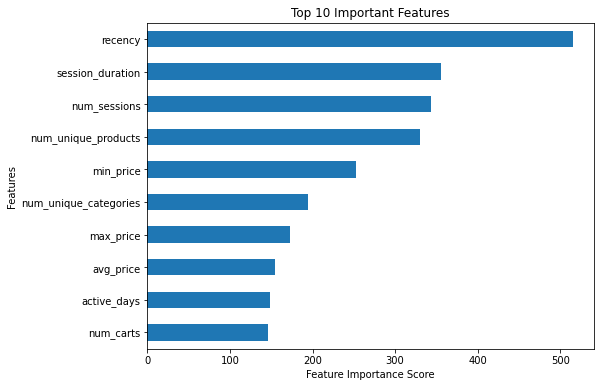

Churn prediction process completed.


In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import joblib
import warnings

warnings.filterwarnings('ignore')

def optimize_dtypes(df):
    """
    Optimize data types to reduce memory usage.
    """
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df

def train_model(X_train, y_train):
    """
    Trains a LightGBM classifier to predict churn.
    """
    print("Starting model training...")
    
    # Handle class imbalance using SMOTE
    smote = SMOTE(random_state=42)
    
    # Define the classifier with reduced complexity
    lgbm = LGBMClassifier(random_state=42, n_jobs=-1, n_estimators=100)
    
    # Create a pipeline with scaling, SMOTE, and the classifier
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', smote),
        ('classifier', lgbm)
    ])
    
    # Simplified hyperparameter tuning
    param_grid = {
        'classifier__max_depth': [3, 5],
        'classifier__learning_rate': [0.01, 0.1],
    }
    
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=4,  # Reduced number of iterations
        scoring='roc_auc',
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    print(f"Best parameters found: {search.best_params_}")
    return search.best_estimator_

# Load prepared data
prepared_data_file = 'prepared_data.pkl'
if os.path.exists(prepared_data_file):
    print(f"Prepared data found at {prepared_data_file}. Loading it...")
    # Load the data
    data = pd.read_pickle(prepared_data_file)
    
    # Sample a subset of the data (e.g., 10%) to reduce memory usage
    sample_size = int(len(data) * 0.1)
    data = data.sample(n=sample_size, random_state=42)
    
    # Optimize data types
    data = optimize_dtypes(data)
else:
    print("Prepared data not found. Please run the previous cell to prepare data.")
    exit()

# Handle the 'month' column
if data['month'].dtype.name == 'period[M]':
    # Convert period to timestamp (end of the month)
    data['month'] = data['month'].dt.to_timestamp(how='end')
elif data['month'].dtype != 'datetime64[ns]':
    # If it's not already datetime, try to convert
    data['month'] = pd.to_datetime(data['month'])

# Split the data into training and testing sets based on months
print("Splitting data into training and testing sets...")
months = sorted(data['month'].unique())
train_months = months[:-2]  # Use all months except the last two for training
test_months = months[-2:]   # Use the last two months for testing

# Create training and testing datasets
train_data = data[data['month'].isin(train_months)].reset_index(drop=True)
test_data = data[data['month'].isin(test_months)].reset_index(drop=True)

# Separate features and target variable
print("Separating features and target variable...")
X_train = train_data.drop(['user_id', 'month', 'churn'], axis=1)
y_train = train_data['churn']
X_test = test_data.drop(['user_id', 'month', 'churn'], axis=1)
y_test = test_data['churn']

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Train the model or load it if already trained
model_file = 'churn_prediction_model.pkl'
if os.path.exists(model_file):
    print(f"Model found at {model_file}. Loading it...")
    model = joblib.load(model_file)
else:
    print("Training the model...")
    model = train_model(X_train, y_train)
    # Save the trained model for future use
    joblib.dump(model, model_file)
    print(f"\nModel training complete and saved as '{model_file}'.")

# Make predictions on the test set
print("Making predictions on the test set...")
y_pred = model.predict(X_test)

# Evaluate the model
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

# Calculate ROC-AUC Score
if hasattr(model.named_steps['classifier'], 'predict_proba'):
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
else:
    print("ROC-AUC Score cannot be calculated for this classifier.")

# Plot the confusion matrix
print("Plotting confusion matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Retained', 'Churned'],
    yticklabels=['Retained', 'Churned']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Display feature importance
if hasattr(model.named_steps['classifier'], 'feature_importances_'):
    print("Displaying feature importance...")
    importances = model.named_steps['classifier'].feature_importances_
    feat_importances = pd.Series(importances, index=X_train.columns)
    feat_importances = feat_importances.sort_values(ascending=False)

    # Plot the top 10 important features
    plt.figure(figsize=(8, 6))
    feat_importances.head(10).plot(kind='barh')
    plt.xlabel('Feature Importance Score')
    plt.ylabel('Features')
    plt.title('Top 10 Important Features')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Feature importance is not available for this classifier.")

print("Churn prediction process completed.")